# Kalibracija kamere pomoću vlastitih slika šahovske ploče

**Student:** Perica Rajčević
**Predmet:** Računalni vid

U ovom notebooku provodi se praktični dio projekta: kalibracija kamere pomoću biblioteke OpenCV na vlastito snimljenom skupu od 30 fotografija šahovske ploče, snimljenih iz različitih kutova i udaljenosti. Detektiraju se unutarnji kutovi kalibracijskog uzorka, izračunavaju parametri kamere (fokalna duljina, optičko središte, koeficijenti distorzije), provodi se korekcija distorzije (undistortion) uz usporedbu originalne i ispravljene slike, a metoda se evaluira izračunom re-projekcijske pogreške.

Teorijska pozadina (projekcijski model kamere, intrinzični i ekstrinzični parametri, radijalna i tangencijalna distorzija, postupak kalibracije) detaljno je obrađena u pripadajućem seminarskom radu

> Napomena: korištena je printana šahovska ploča s **9 × 7 kvadrata**, što odgovara uzorku od **8 × 6 unutarnjih kutova** u OpenCV-u.


## Kratki teorijski podsjetnik

Kalibracijom se određuju parametri projekcijskog modela kamere $s\,[u\ v\ 1]^T = K\,[R\,|\,t]\,[X\ Y\ Z\ 1]^T$:

- **Intrinzični parametri** — matrica kamere $K$ sadrži fokalne duljine u pikselima ($f_x, f_y$) i optičko središte ($c_x, c_y$); konstantni su za danu kameru.
- **Ekstrinzični parametri** — rotacija $R$ i translacija $t$ kamere u odnosu na uzorak; različiti za svaku sliku (`rvecs`, `tvecs`).
- **Koeficijenti distorzije** $(k_1, k_2, p_1, p_2, k_3)$ — $k_i$ opisuju radijalnu distorziju (jače lomljenje zraka na rubu leće, raste prema rubovima slike), a $p_1, p_2$ tangencijalnu (leća nije savršeno paralelna sa senzorom).
- **Re-projekcijska pogreška** — RMS udaljenost (u pikselima) između detektiranih kutova i istih točaka projiciranih natrag na sliku procijenjenim parametrima; vrijednosti ispod 1 px smatraju se dobrom kalibracijom.


## 1. Priprema okruženja

Učitavaju se potrebne biblioteke i kreiraju folderi za ulazne slike, rezultate, grafove i parametre kalibracije.

In [15]:
import os
import glob
import shutil
import zipfile

import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

print("OpenCV verzija:", cv.__version__)

# Glavni folderi projekta
os.makedirs("data/chessboard", exist_ok=True)
os.makedirs("results/detected_corners", exist_ok=True)
os.makedirs("results/undistorted", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)
os.makedirs("results/calibration_parameters", exist_ok=True)

def read_image_bgr(path):
    """
    Učitava sliku uz poštivanje EXIF orijentacije.
    Ovo je važno za fotografije s mobitela jer OpenCV ponekad ne pročita rotaciju slike pravilno.
    Funkcija vraća sliku u BGR formatu, kao cv.imread.
    """
    try:
        img_pil = Image.open(path)
        img_pil = ImageOps.exif_transpose(img_pil)
        img_rgb = np.array(img_pil.convert("RGB"))
        img_bgr = cv.cvtColor(img_rgb, cv.COLOR_RGB2BGR)
        return img_bgr
    except Exception as e:
        print("Greška pri učitavanju slike:", path, e)
        return None

print("Okruženje je spremno.")

OpenCV verzija: 4.13.0
Okruženje je spremno.


## 2. Postavke kalibracijskog uzorka

OpenCV-u se ne zadaje broj kvadrata, nego broj **unutarnjih kutova**.  
Korištena printana ploča ima 9 × 7 kvadrata, pa se u kodu koristi `PATTERN_SIZE = (8, 6)`.

Veličina jednog kvadrata postavljena je na 30 mm. Ako je pri printanju došlo do promjene skale, treba izmjeriti kvadrat ravnalom i ovdje upisati stvarnu vrijednost.

In [16]:
# Broj unutarnjih kutova šahovske ploče
# Fizička ploča(print slika): 9 x 7 kvadrata -> OpenCV uzorak: 8 x 6 unutarnjih kutova
PATTERN_SIZE = (8, 6)

# Veličina jednog kvadrata u milimetrima(sa papira)
SQUARE_SIZE = 30.0

print("Uzorak unutarnjih kutova:", PATTERN_SIZE)
print("Veličina kvadrata:", SQUARE_SIZE, "mm")

Uzorak unutarnjih kutova: (8, 6)
Veličina kvadrata: 30.0 mm


## 3. Učitavanje vlastito snimljenih slika

U ovom koraku koriste se vlastito snimljene fotografije šahovske ploče.  
Ako folder `my_chessboard` već postoji u Colabu, slike će se automatski učitati iz njega. Ako folder ne postoji, pojavit će se opcija za ručni upload slika ili ZIP datoteke.

Broj vlastito snimljenih slika: 30
Prvih nekoliko slika:
- IMG_4552.jpeg
- IMG_4553.jpeg
- IMG_4554.jpeg
- IMG_4555.jpeg
- IMG_4556.jpeg


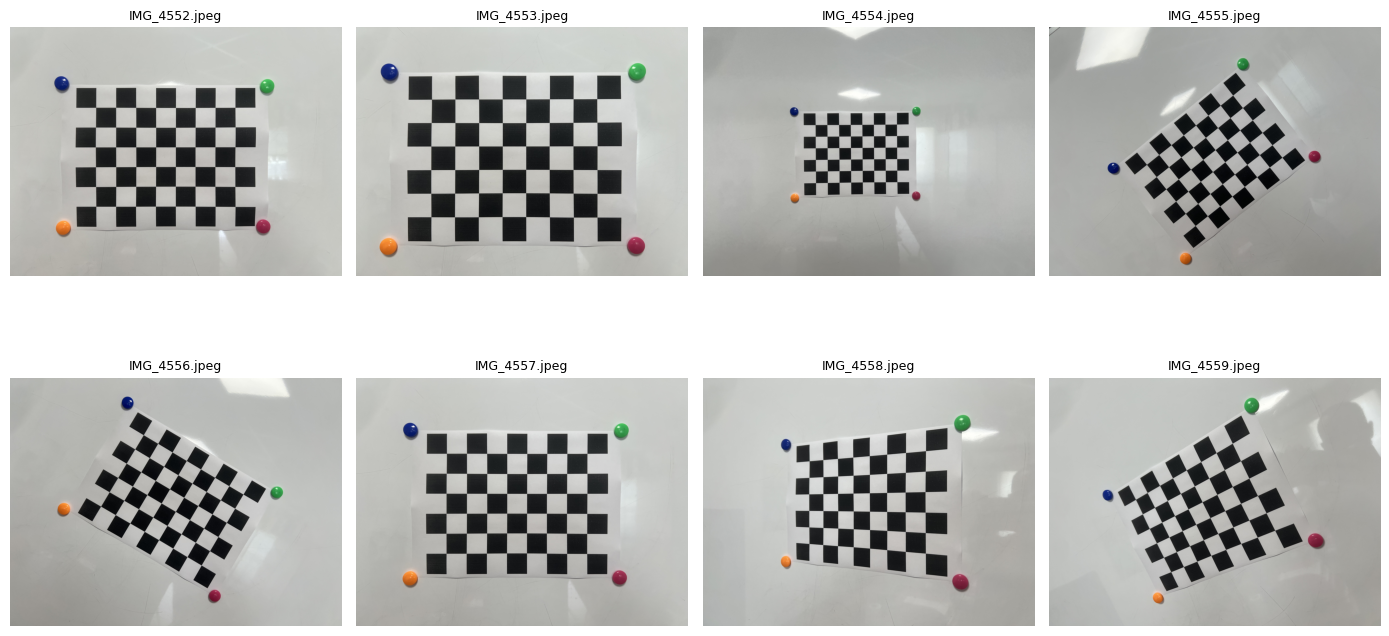

In [17]:
# Folder u kojem su upload-ovane moje fotografije
source_folder = "my_chessboard"

# Ako folder ne postoji, omogućava se ručni upload slika
if not os.path.exists(source_folder):
    print("Folder 'my_chessboard' nije pronađen.")
    print("Uploaduj JPG/PNG slike ili jedan ZIP sa slikama.")

    from google.colab import files
    uploaded = files.upload()

    os.makedirs(source_folder, exist_ok=True)

    for filename in uploaded.keys():
        if filename.lower().endswith(".zip"):
            with zipfile.ZipFile(filename, "r") as zip_ref:
                zip_ref.extractall(source_folder)
            os.remove(filename)
        elif filename.lower().endswith((".jpg", ".jpeg", ".png")):
            shutil.move(filename, os.path.join(source_folder, filename))
        else:
            print("Preskačem nepodržan format:", filename)

# Brišem stare slike iz radnog foldera da se ne pomiješaju s prethodnim datasetom
shutil.rmtree("data/chessboard", ignore_errors=True)
os.makedirs("data/chessboard", exist_ok=True)

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

# Pronalazak slika u folderu my_chessboard, uključujući eventualne podfoldere
source_images = []
for ext in image_extensions:
    source_images.extend(glob.glob(os.path.join(source_folder, "**", ext), recursive=True))

source_images = sorted(source_images)

if len(source_images) == 0:
    raise ValueError("Nije pronađena nijedna JPG/PNG slika. Provjeri folder 'my_chessboard'.")

# Kopiranje slika u radni folder
for img_path in source_images:
    filename = os.path.basename(img_path)
    destination = os.path.join("data/chessboard", filename)
    shutil.copy2(img_path, destination)

image_files = []
for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join("data/chessboard", ext)))

image_files = sorted(image_files)

print("Broj vlastito snimljenih slika:", len(image_files))
print("Prvih nekoliko slika:")
for p in image_files[:5]:
    print("-", os.path.basename(p))

# Prikaz prvih 8 ulaznih slika
plt.figure(figsize=(14, 8))

for idx, p in enumerate(image_files[:8]):
    img = read_image_bgr(p)

    if img is None:
        continue

    plt.subplot(2, 4, idx + 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(os.path.basename(p), fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.savefig("results/plots/input_images.png", dpi=150)
plt.show()

## 4. Detekcija unutarnjih kutova šahovske ploče

Za svaku sliku detektiraju se unutarnji kutovi šahovske ploče.  
Poznate 3D točke uzorka povezuju se s detektiranim 2D točkama u slici. To je osnova za izračun parametara kamere.

Ako je neka slika mutna, previše zakrenuta, ima odsjaj ili šahovska ploča nije potpuno vidljiva, detekcija može ne uspjeti.

Nakon detekcije funkcijom `findChessboardCorners`, položaj kutova precizira se na subpikselnu razinu pomoću `cornerSubPix`, a svakom 2D kutu pridružuje se poznata 3D koordinata na ploči (ploča definira ravninu $Z = 0$, razmak kutova jednak je veličini kvadrata).


In [18]:
# Čišćenje starih rezultata detekcije
shutil.rmtree("results/detected_corners", ignore_errors=True)
os.makedirs("results/detected_corners", exist_ok=True)

# Folder za resized slike koje ću se koristiti za kalibraciju
shutil.rmtree("data/chessboard_resized", ignore_errors=True)
os.makedirs("data/chessboard_resized", exist_ok=True)

# Maksimalna širina slike za obradu(zbog veličine slika)
MAX_WIDTH = 1600

criteria = (
    cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER,
    30,
    0.001
)

def resize_for_processing(img, max_width=1600):
    h, w = img.shape[:2]

    if w <= max_width:
        return img

    scale = max_width / w
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv.resize(img, (new_w, new_h), interpolation=cv.INTER_AREA)
    return resized

def create_object_points(pattern_size, square_size):
    objp = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[
        0:pattern_size[0],
        0:pattern_size[1]
    ].T.reshape(-1, 2)

    objp *= square_size
    return objp

objpoints = []
imgpoints = []
valid_files = []
failed_files = []
image_size = None

# Pošto je printana ploča 9 x 7 kvadrata, OpenCV traži 8 x 6 unutarnjih kutova
pattern_candidates = [
    PATTERN_SIZE,
    (PATTERN_SIZE[1], PATTERN_SIZE[0])
]

for img_path in image_files:
    img_original = read_image_bgr(img_path)

    if img_original is None:
        failed_files.append(img_path)
        continue

    # Smanjujem velicinu slika zbog brze obrade
    img = resize_for_processing(img_original, MAX_WIDTH)

    # Spremam resized verziju jer se na njoj radi kalibracija
    resized_name = os.path.splitext(os.path.basename(img_path))[0] + "_resized.jpg"
    resized_path = os.path.join("data/chessboard_resized", resized_name)
    cv.imwrite(resized_path, img)

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    image_size = gray.shape[::-1]

    found = False
    best_corners = None
    best_pattern = None

    for current_pattern in pattern_candidates:
        # Prvo koristim bržu klasična metoda
        ret, corners = cv.findChessboardCorners(
            gray,
            current_pattern,
            flags=cv.CALIB_CB_ADAPTIVE_THRESH + cv.CALIB_CB_NORMALIZE_IMAGE
        )

        # Ako ne uspije, pokušat ću sa SB metododom, ali bez presporih exhaustive opcija
        if not ret and hasattr(cv, "findChessboardCornersSB"):
            ret, corners = cv.findChessboardCornersSB(
                gray,
                current_pattern,
                flags=cv.CALIB_CB_NORMALIZE_IMAGE
            )

        if ret:
            found = True
            best_corners = corners
            best_pattern = current_pattern
            break

    if found:
        best_corners = np.asarray(best_corners, dtype=np.float32)

        corners_refined = cv.cornerSubPix(
            gray,
            best_corners,
            (11, 11),
            (-1, -1),
            criteria
        )

        objp = create_object_points(best_pattern, SQUARE_SIZE)

        objpoints.append(objp)
        imgpoints.append(corners_refined)
        valid_files.append(resized_path)

        drawn = img.copy()
        cv.drawChessboardCorners(drawn, best_pattern, corners_refined, True)

        output_name = os.path.splitext(os.path.basename(img_path))[0] + "_corners.jpg"
        output_path = os.path.join("results/detected_corners", output_name)
        cv.imwrite(output_path, drawn)

    else:
        failed_files.append(img_path)

print("Ukupan broj slika:", len(image_files))
print("Uspješnih detekcija:", len(valid_files))
print("Neuspješnih detekcija:", len(failed_files))
print("Veličina slike za kalibraciju:", image_size)

if failed_files:
    print("\nSlike na kojima detekcija nije uspjela:")
    for f in failed_files:
        print("-", os.path.basename(f))

if len(valid_files) < 10:
    print("\nUPOZORENJE: Imamo manje od 10 uspješnih detekcija.")
    print("Ako bude premalo uspješnih slika, treba ponovo slikati jasnije i iz više kutova.")
else:
    print("\nBroj uspješnih detekcija je dovoljan za nastavak kalibracije.")

Ukupan broj slika: 30
Uspješnih detekcija: 30
Neuspješnih detekcija: 0
Veličina slike za kalibraciju: (1600, 1200)

Broj uspješnih detekcija je dovoljan za nastavak kalibracije.


## 5. Prikaz detektiranih kutova

Na sljedećim slikama prikazani su detektirani unutarnji kutovi šahovske ploče.  
Ove slike su rezultat vlastite implementacije nad vlastito snimljenim fotografijama.

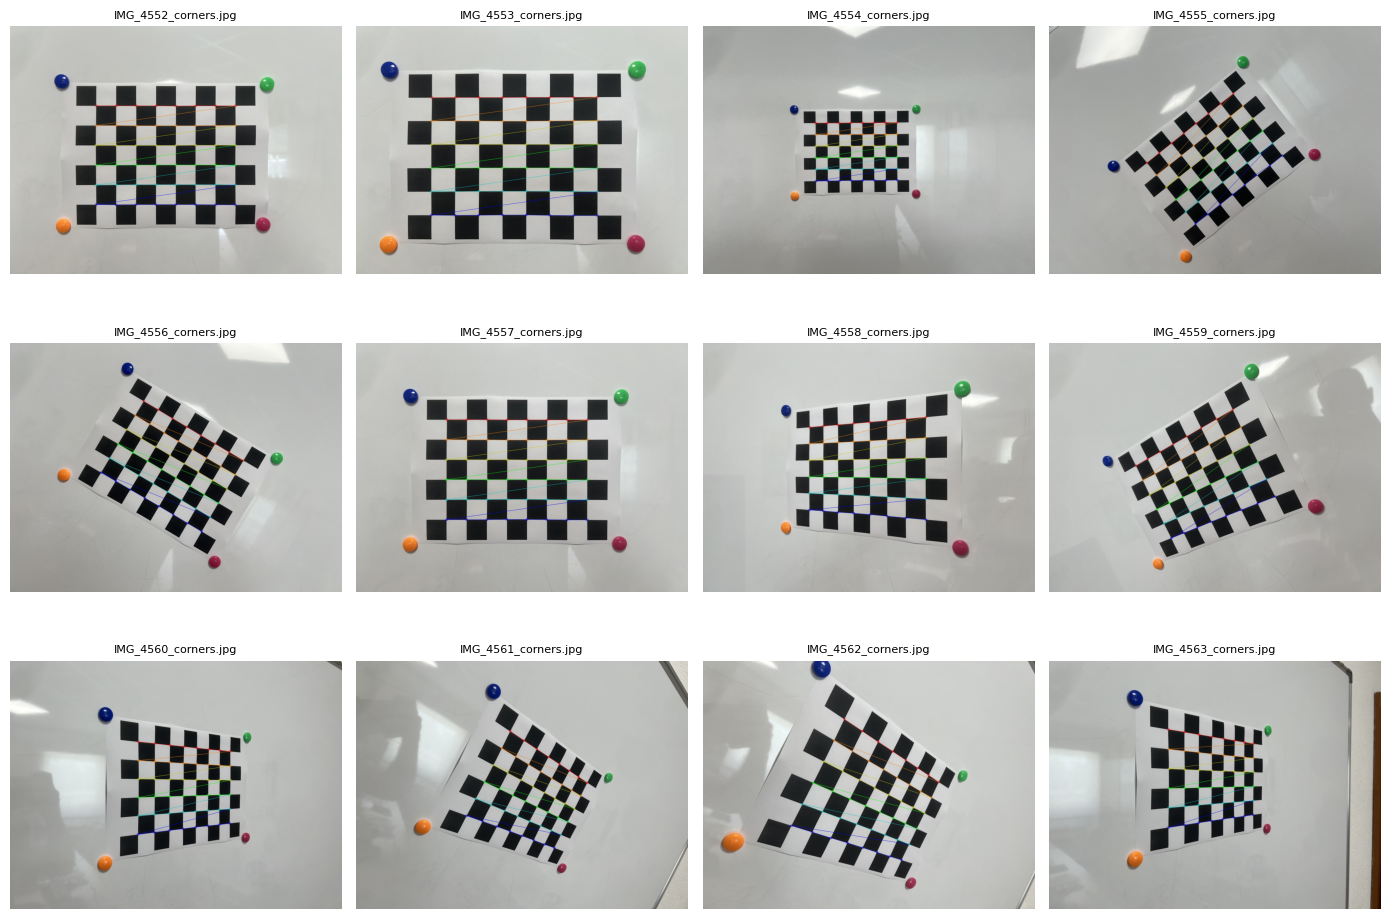

In [19]:
corner_images = sorted(glob.glob("results/detected_corners/*_corners.jpg"))

if len(corner_images) == 0:
    raise ValueError("Nema spremljenih slika s detektiranim kutovima.")

plt.figure(figsize=(14, 10))

for idx, p in enumerate(corner_images[:12]):
    img = read_image_bgr(p)

    if img is None:
        continue

    plt.subplot(3, 4, idx + 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(os.path.basename(p), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.savefig("results/plots/detected_corners.png", dpi=150)
plt.show()

## 6. Kalibracija kamere

Funkcija `calibrateCamera` koristi parove 3D i 2D točaka kako bi izračunala:

- intrinzičnu matricu kamere,
- koeficijente distorzije,
- rotacijske i translacijske vektore za svaku sliku,
- RMS re-projekcijsku pogrešku.

Funkcija interno provodi početnu procjenu parametara iz homografija te nelinearnu optimizaciju (Levenberg–Marquardt) kojom minimizira ukupnu re-projekcijsku pogrešku, pa je vraćena RMS vrijednost izravna mjera kvalitete kalibracije.


In [20]:
if len(objpoints) < 5:
    raise ValueError("Premalo uspješnih detekcija za kalibraciju. Potrebno je snimiti bolje slike.")

rms_error, camera_matrix, dist_coeffs, rvecs, tvecs = cv.calibrateCamera(
    objpoints,
    imgpoints,
    image_size,
    None,
    None
)

print("Broj slika korištenih za kalibraciju:", len(objpoints))
print("Veličina slike:", image_size)

print("\nRMS re-projekcijska pogreška:")
print(rms_error)

print("\nMatrica kamere:")
print(camera_matrix)

print("\nKoeficijenti distorzije:")
print(dist_coeffs)

Broj slika korištenih za kalibraciju: 30
Veličina slike: (1600, 1200)

RMS re-projekcijska pogreška:
0.9518936126690285

Matrica kamere:
[[1.22052097e+03 0.00000000e+00 7.95921157e+02]
 [0.00000000e+00 1.21800301e+03 6.15800501e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Koeficijenti distorzije:
[[ 0.31940674 -2.0326806   0.00523627 -0.00358789  3.39090217]]


## 7. Tablični prikaz parametara

Dobivena matrica kamere sadrži fokalne duljine `fx`, `fy` i optičko središte `cx`, `cy`.  
Koeficijenti distorzije opisuju radijalnu i tangencijalnu distorziju leće.

In [21]:
fx = camera_matrix[0, 0]
fy = camera_matrix[1, 1]
cx = camera_matrix[0, 2]
cy = camera_matrix[1, 2]

dist = dist_coeffs.ravel()

param_names = ["fx", "fy", "cx", "cy", "k1", "k2", "p1", "p2", "k3"]

param_values = [
    fx,
    fy,
    cx,
    cy,
    dist[0],
    dist[1],
    dist[2],
    dist[3],
    dist[4] if len(dist) > 4 else np.nan
]

results_table = pd.DataFrame({
    "Parametar": param_names,
    "Vrijednost": param_values
})

results_table.to_csv("results/tables/calibration_parameters.csv", index=False)

results_table

,Parametar,Vrijednost
0,fx,1220.520972
1,fy,1218.003013
2,cx,795.921157
3,cy,615.800501
4,k1,0.319407
5,k2,-2.032681
6,p1,0.005236
7,p2,-0.003588
8,k3,3.390902


## 8. Re-projekcijska pogreška

Re-projekcijska pogreška pokazuje koliko se ponovno projicirane 3D točke razlikuju od stvarno detektiranih 2D točaka u slici.  
Manja vrijednost znači da izračunati model kamere bolje opisuje proces nastanka slike.

Pogreška se ovdje računa vlastitom implementacijom (funkcijom `projectPoints` projiciraju se 3D točke natrag na sliku), što ujedno služi i kao provjera: globalni RMSE mora se poklapati s RMS vrijednošću koju je vratila funkcija `calibrateCamera`.


In [22]:
mean_errs = []
rmse_errs = []
all_squared_errors = []

for i in range(len(objpoints)):
    projected_points, _ = cv.projectPoints(
        objpoints[i],
        rvecs[i],
        tvecs[i],
        camera_matrix,
        dist_coeffs
    )

    detected = imgpoints[i].reshape(-1, 2)
    projected = projected_points.reshape(-1, 2)

    errors = np.linalg.norm(detected - projected, axis=1)

    mean_error = np.mean(errors)
    rmse_error = np.sqrt(np.mean(errors ** 2))

    mean_errs.append(mean_error)
    rmse_errs.append(rmse_error)
    all_squared_errors.extend(errors ** 2)

global_mean = np.mean(mean_errs)
global_rmse = np.sqrt(np.mean(all_squared_errors))

print("Prosječna re-projekcijska pogreška:", global_mean)
print("Globalni RMSE:", global_rmse)

error_table = pd.DataFrame({
    "Slika": [os.path.basename(p) for p in valid_files],
    "Prosječna pogreška [px]": mean_errs,
    "RMSE [px]": rmse_errs
})

error_table.to_csv("results/tables/reprojection_errors.csv", index=False)

error_table

Prosječna re-projekcijska pogreška: 0.62547606
Globalni RMSE: 0.9518935


,Slika,Prosječna pogreška [px],RMSE [px]
0,IMG_4552_resized.jpg,0.483197,0.569519
1,IMG_4553_resized.jpg,0.544767,0.613694
2,IMG_4554_resized.jpg,0.207136,0.236834
3,IMG_4555_resized.jpg,0.863163,1.737220
4,IMG_4556_resized.jpg,0.355457,0.391420
5,IMG_4557_resized.jpg,0.428405,0.477607
6,IMG_4558_resized.jpg,0.540995,0.649042
7,IMG_4559_resized.jpg,0.558225,0.661144
8,IMG_4560_resized.jpg,0.500317,0.608118
9,IMG_4561_resized.jpg,0.513989,0.638252


## 9. Graf re-projekcijske pogreške

Graf prikazuje RMSE pogrešku po svakoj slici.  
Slike s većom pogreškom mogu biti mutnije, imati lošiji kut snimanja ili slabiju detekciju kutova.

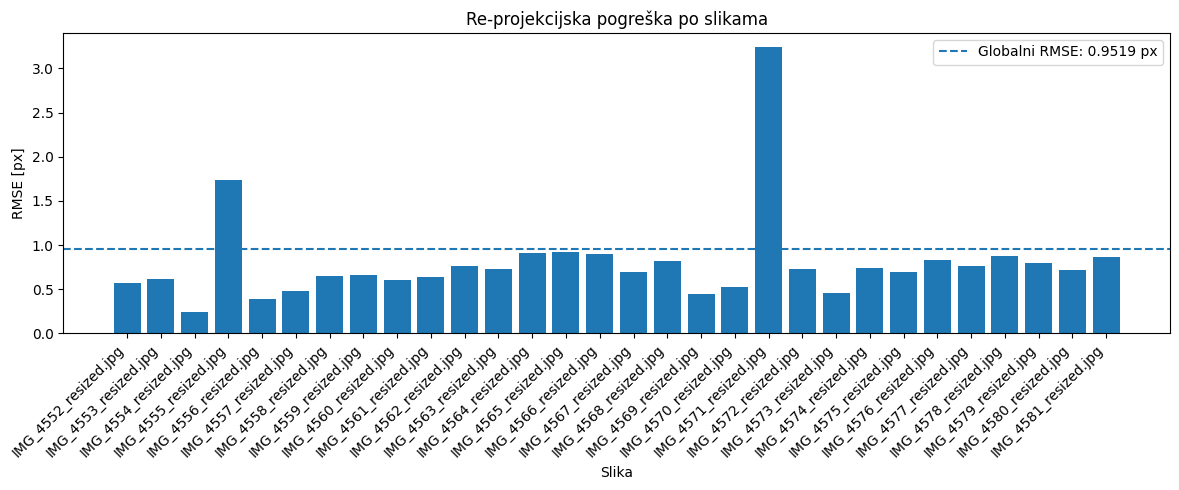

In [23]:
plt.figure(figsize=(12, 5))

plt.bar(
    [os.path.basename(p) for p in valid_files],
    rmse_errs
)

plt.axhline(
    global_rmse,
    linestyle="--",
    label=f"Globalni RMSE: {global_rmse:.4f} px"
)

plt.title("Re-projekcijska pogreška po slikama")
plt.xlabel("Slika")
plt.ylabel("RMSE [px]")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

plt.savefig("results/plots/reprojection_error.png", dpi=150)
plt.show()

## 10. Korekcija distorzije na jednoj slici

Dobiveni parametri koriste se za ispravljanje geometrijske distorzije slike.  
Prikazana je originalna slika i dvije ispravljene verzije:

- `alpha = 1`: zadržava više slike, ali mogu ostati crni rubovi,
- `alpha = 0`: više reže sliku, ali smanjuje crne rubove.

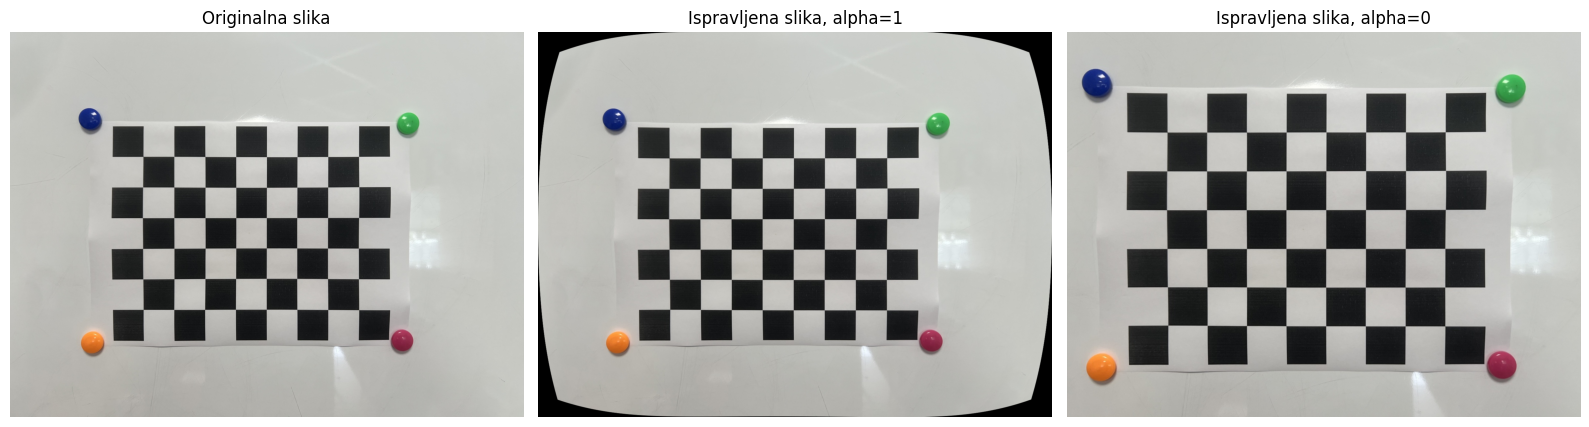

Korištena slika: IMG_4552_resized.jpg
ROI alpha=1: (165, 151, 1251, 938)
ROI alpha=0: (0, 0, 1599, 1199)


In [24]:
# Biram prvu uspješnu sliku za prikaz korekcije distorzije
example_index = 0

img = read_image_bgr(valid_files[example_index])

if img is None:
    raise ValueError("Nije moguće učitati primjer slike za korekciju distorzije.")

h, w = img.shape[:2]

# alpha = 1 zadržava veći dio slike, ali mogu ostati crni rubovi
new_mtx_a1, roi_a1 = cv.getOptimalNewCameraMatrix(
    camera_matrix,
    dist_coeffs,
    (w, h),
    1,
    (w, h)
)

undist_a1 = cv.undistort(
    img,
    camera_matrix,
    dist_coeffs,
    None,
    new_mtx_a1
)

# alpha = 0 više reže sliku i smanjuje crne rubove
new_mtx_a0, roi_a0 = cv.getOptimalNewCameraMatrix(
    camera_matrix,
    dist_coeffs,
    (w, h),
    0,
    (w, h)
)

undist_a0 = cv.undistort(
    img,
    camera_matrix,
    dist_coeffs,
    None,
    new_mtx_a0
)

cv.imwrite("results/undistorted/original_example.jpg", img)
cv.imwrite("results/undistorted/undistorted_alpha1.jpg", undist_a1)
cv.imwrite("results/undistorted/undistorted_alpha0.jpg", undist_a0)

plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Originalna slika")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(undist_a1, cv.COLOR_BGR2RGB))
plt.title("Ispravljena slika, alpha=1")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(undist_a0, cv.COLOR_BGR2RGB))
plt.title("Ispravljena slika, alpha=0")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/plots/original_vs_undistorted.png", dpi=150)
plt.show()

print("Korištena slika:", os.path.basename(valid_files[example_index]))
print("ROI alpha=1:", roi_a1)
print("ROI alpha=0:", roi_a0)

## 11. Vizualizacija korekcije pomoću sintetičke mreže

Sintetička mreža pomaže u prikazu oblika geometrijske korekcije.  
Na njoj je lakše vidjeti kako dobiveni parametri distorzije mijenjaju geometriju slike.

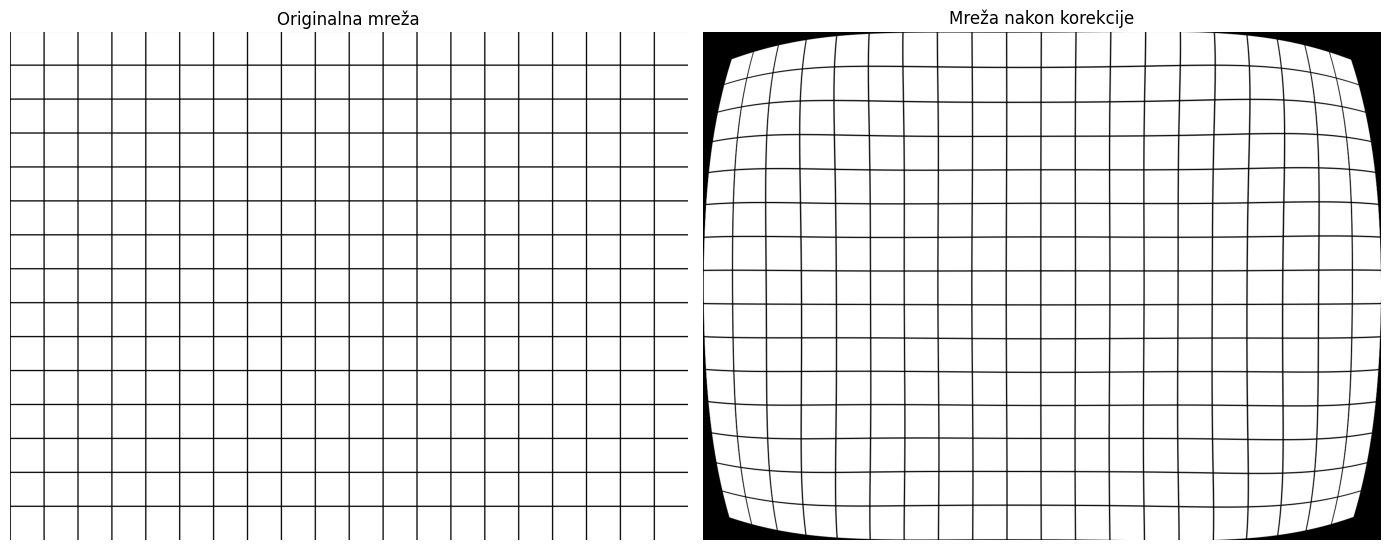

In [25]:
def create_grid_image(width, height, step=80):
    grid = np.ones((height, width, 3), dtype=np.uint8) * 255

    for x in range(0, width, step):
        cv.line(grid, (x, 0), (x, height), (0, 0, 0), 2)

    for y in range(0, height, step):
        cv.line(grid, (0, y), (width, y), (0, 0, 0), 2)

    return grid

h, w = img.shape[:2]

grid = create_grid_image(w, h, step=max(50, w // 20))

grid_corrected = cv.undistort(
    grid,
    camera_matrix,
    dist_coeffs,
    None,
    new_mtx_a1
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(grid, cv.COLOR_BGR2RGB))
plt.title("Originalna mreža")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(grid_corrected, cv.COLOR_BGR2RGB))
plt.title("Mreža nakon korekcije")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/plots/grid_correction.png", dpi=150)
plt.show()

## 12. Korekcija distorzije na svim uspješnim slikama

Nakon kalibracije, korekcija distorzije primjenjuje se na sve slike na kojima je uspješno detektiran kalibracijski uzorak.

Broj ispravljenih slika: 30


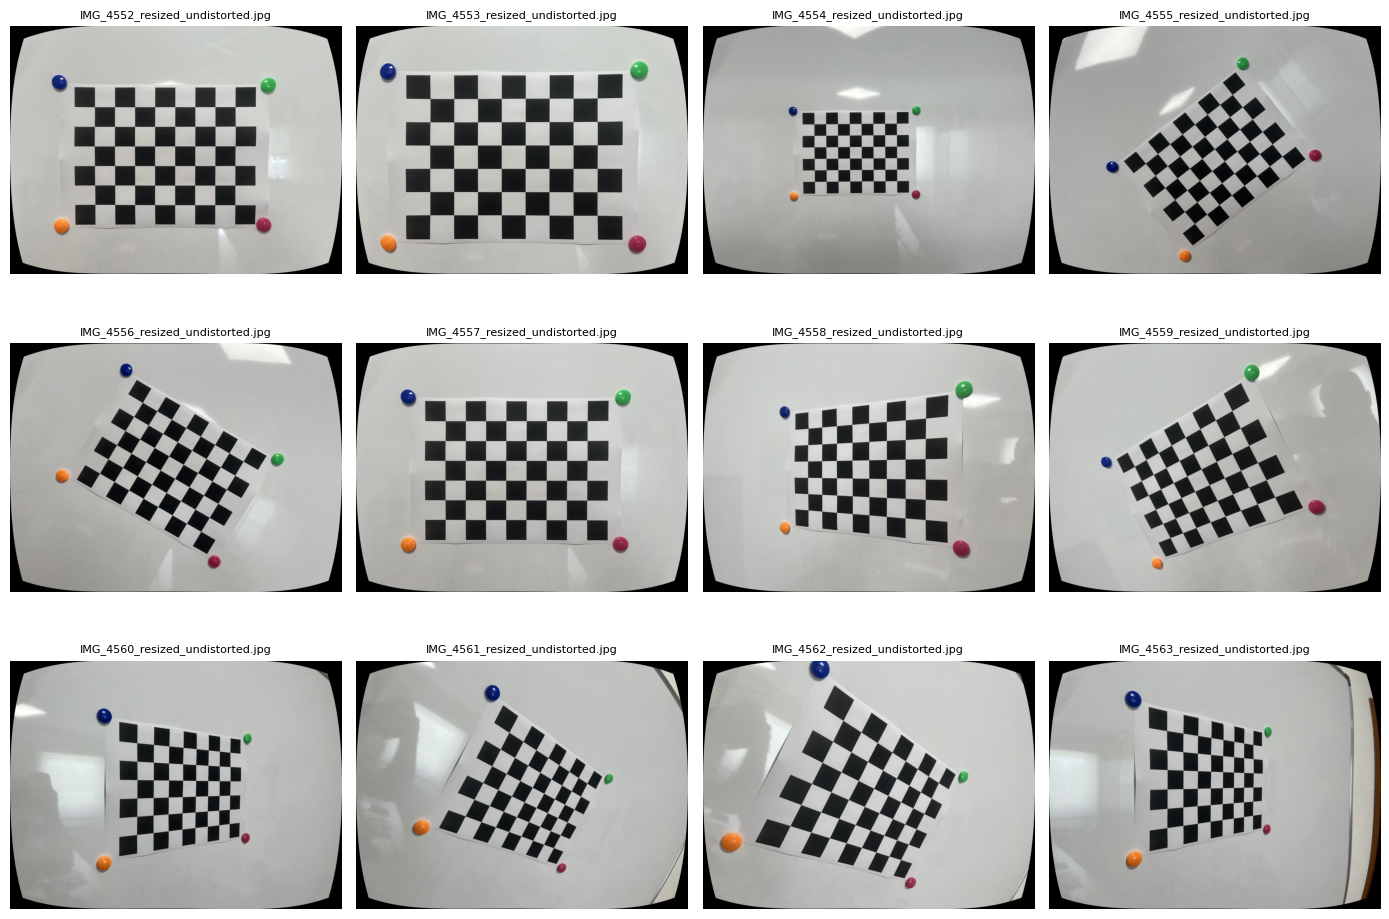

In [26]:
# Čišćenje starih ispravljenih slika
for old_file in glob.glob("results/undistorted/*_undistorted.jpg"):
    os.remove(old_file)

undistorted_paths = []

for img_path in valid_files:
    img_cur = read_image_bgr(img_path)

    if img_cur is None:
        continue

    hc, wc = img_cur.shape[:2]

    new_m, _ = cv.getOptimalNewCameraMatrix(
        camera_matrix,
        dist_coeffs,
        (wc, hc),
        1,
        (wc, hc)
    )

    undistorted = cv.undistort(
        img_cur,
        camera_matrix,
        dist_coeffs,
        None,
        new_m
    )

    output_name = os.path.splitext(os.path.basename(img_path))[0] + "_undistorted.jpg"
    output_path = os.path.join("results/undistorted", output_name)

    cv.imwrite(output_path, undistorted)
    undistorted_paths.append(output_path)

print("Broj ispravljenih slika:", len(undistorted_paths))

plt.figure(figsize=(14, 10))

for idx, p in enumerate(undistorted_paths[:12]):
    img_show = read_image_bgr(p)

    if img_show is None:
        continue

    plt.subplot(3, 4, idx + 1)
    plt.imshow(cv.cvtColor(img_show, cv.COLOR_BGR2RGB))
    plt.title(os.path.basename(p), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.savefig("results/plots/all_undistorted.png", dpi=150)
plt.show()

## 13. Spremanje parametara kalibracije

Izračunati parametri spremaju se u `.npz` datoteku kako bi se kasnije mogli ponovno koristiti bez ponavljanja cijelog postupka kalibracije.

In [27]:
np.savez(
    "results/calibration_parameters/camera_calibration.npz",
    camera_matrix=camera_matrix,
    dist_coeffs=dist_coeffs,
    rvecs=np.array(rvecs, dtype=object),
    tvecs=np.array(tvecs, dtype=object),
    rms_error=rms_error,
    global_mean_error=global_mean,
    global_rmse=global_rmse,
    per_image_mean_errors=np.array(mean_errs),
    per_image_rmse=np.array(rmse_errs),
    pattern_size=np.array(PATTERN_SIZE),
    square_size=SQUARE_SIZE,
    image_size=np.array(image_size),
    valid_files=np.array(valid_files)
)

summary_text = f"""
SAŽETAK REZULTATA KALIBRACIJE KAMERE

Korištene su vlastito snimljene slike šahovske ploče.
Ukupan broj slika: {len(image_files)}
Broj uspješnih detekcija: {len(valid_files)}
Veličina slike: {image_size[0]} x {image_size[1]} px

Uzorak šahovske ploče: {PATTERN_SIZE[0]} x {PATTERN_SIZE[1]} unutarnjih kutova
Veličina kvadrata: {SQUARE_SIZE} mm

RMS re-projekcijska pogreška iz calibrateCamera: {rms_error:.6f} px
Prosječna re-projekcijska pogreška: {global_mean:.6f} px
Globalni RMSE: {global_rmse:.6f} px

Matrica kamere:
{camera_matrix}

Koeficijenti distorzije:
{dist_coeffs}
"""

print(summary_text)

with open("results/calibration_parameters/summary_results.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Parametri spremljeni u:")
print("results/calibration_parameters/camera_calibration.npz")
print("Sažetak spremljen u:")
print("results/calibration_parameters/summary_results.txt")


SAŽETAK REZULTATA KALIBRACIJE KAMERE

Korištene su vlastito snimljene slike šahovske ploče.
Ukupan broj slika: 30
Broj uspješnih detekcija: 30
Veličina slike: 1600 x 1200 px

Uzorak šahovske ploče: 8 x 6 unutarnjih kutova
Veličina kvadrata: 30.0 mm

RMS re-projekcijska pogreška iz calibrateCamera: 0.951894 px
Prosječna re-projekcijska pogreška: 0.625476 px
Globalni RMSE: 0.951894 px

Matrica kamere:
[[1.22052097e+03 0.00000000e+00 7.95921157e+02]
 [0.00000000e+00 1.21800301e+03 6.15800501e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Koeficijenti distorzije:
[[ 0.31940674 -2.0326806   0.00523627 -0.00358789  3.39090217]]

Parametri spremljeni u:
results/calibration_parameters/camera_calibration.npz
Sažetak spremljen u:
results/calibration_parameters/summary_results.txt


## 14. Opcionalno: pakiranje rezultata

Ovaj korak nije potreban za samu kalibraciju, ali može biti koristan za preuzimanje svih generiranih rezultata iz Colaba.

In [28]:
if os.path.exists("rezultati_kalibracije.zip"):
    os.remove("rezultati_kalibracije.zip")

shutil.make_archive("rezultati_kalibracije", "zip", "results")

print("ZIP datoteka je kreirana:")
print("rezultati_kalibracije.zip")

ZIP datoteka je kreirana:
rezultati_kalibracije.zip


---
## 15. Analiza i interpretacija rezultata

### Uspješnost detekcije

Kalibracijski uzorak uspješno je detektiran na **svih 30 od 30 vlastito snimljenih slika**. Tome je pridonijelo to što je ploča na svim slikama bila u potpunosti vidljiva, dobro osvijetljena i snimljena s dovoljno oštrine, a slike su prije obrade ujednačene na radnu rezoluciju 1600 × 1200 px.

### Intrinzični parametri

- $f_x = 1220.52$ px, $f_y = 1218.00$ px — omjer $f_x / f_y \approx 1.002$ potvrđuje da senzor ima **kvadratne piksele**, kako je i očekivano za kameru mobitela.
- Optičko središte $(795.9,\ 615.8)$ vrlo je blizu geometrijskog središta slike $(800,\ 600)$ — odstupanje od svega ~4 px horizontalno i ~16 px vertikalno uobičajena je posljedica sklapanja kamere.
- Iz fokalne duljine može se procijeniti horizontalni kut vidnog polja: $FOV_h = 2 \arctan\left(\frac{1600}{2 \cdot 1220.5}\right) \approx 66.5°$, što odgovara tipičnoj širokokutnoj kameri pametnog telefona.

### Koeficijenti distorzije

Dobiveni vektor distorzije iznosi $(k_1, k_2, p_1, p_2, k_3) = (0.319,\ -2.033,\ 0.0052,\ -0.0036,\ 3.391)$.

- **Tangencijalni koeficijenti** $p_1$ i $p_2$ vrlo su mali (reda $10^{-3}$): leća je gotovo savršeno paralelna sa senzorom, pa je tangencijalna distorzija zanemariva — u skladu s očekivanjima za tvornički sklopljenu kameru.
- **Radijalni koeficijenti** imaju izmjenične predznake i velike iznose viših članova, što je uobičajeno kod punog modela sa članom $r^6$: pojedinačne koeficijente ne treba interpretirati izolirano jer se članovi polinoma dijelom kompenziraju, a tek njihov zajednički učinak opisuje stvarnu radijalnu distorziju. Taj učinak jasno je vidljiv u usporedbi originalne i ispravljene slike (korak 10) i na sintetičkoj mreži (korak 11), gdje se geometrija najviše mijenja prema rubovima slike — upravo tamo gdje je radijalna distorzija teorijski najizraženija.

### Re-projekcijska pogreška

- RMS iz `calibrateCamera`: **0.9519 px**
- Globalni RMSE iz vlastite implementacije: **0.9519 px**
- Prosječna pogreška po točki: **0.6255 px**

Poklapanje vlastitog izračuna s vrijednošću iz `calibrateCamera` potvrđuje da je evaluacija ispravno implementirana. Pogreška ispod 1 piksela znači da izračunati model kamere vrlo dobro opisuje stvarni proces snimanja.

Analiza po slikama pokazuje da je većina slika u rasponu **0.2 – 0.9 px**, dok jedna slika (`IMG_4571`) odskače s RMSE od **3.24 px** — vjerojatno zbog blage zamućenosti ili preoštrog kuta snimanja. Ta bi se slika mogla isključiti i kalibracija ponoviti, čime bi globalna pogreška dodatno pala; ovdje je zadržana radi transparentnosti prikaza cijelog postupka.

### Korekcija distorzije

Usporedba originalne i ispravljene slike pokazuje očekivano ponašanje dvaju načina korekcije: **alpha = 1** zadržava sve izvorne piksele uz vidljive crne rubove (ROI valjanog područja: 165, 151, 1251, 938), dok **alpha = 0** daje sliku bez crnih rubova uz obrezivanje. Nakon korekcije rubovi ploče i ostale ravne linije postaju ravniji, što vizualno potvrđuje da su procijenjeni koeficijenti distorzije smisleni.


## 16. Zaključak

Provedena je kalibracija kamere na vlastito snimljenom skupu slika šahovske ploče. Glavni rezultati:

1. Uzorak (8 × 6 unutarnjih kutova) uspješno je detektiran na **svih 30 fotografija**.
2. Izračunati su intrinzični parametri kamere: $f_x \approx 1220.5$ px, $f_y \approx 1218.0$ px, optičko središte $(795.9,\ 615.8)$ — vrijednosti fizikalno smislene i u skladu s očekivanjima za kameru mobitela.
3. Procijenjeni su koeficijenti distorzije: tangencijalna komponenta pokazala se zanemarivom, a radijalna jasno vidljivom prema rubovima slike.
4. Provedena je korekcija distorzije uz usporedbu originalne i ispravljene slike te vizualizaciju na sintetičkoj mreži.
5. Kalibracija je evaluirana re-projekcijskom pogreškom: **RMS = 0.95 px** (prosjek 0.63 px po točki), što se smatra dobrom kalibracijom, a vlastiti izračun pogreške poklapa se s vrijednošću iz OpenCV-a.

Mogućnosti poboljšanja: isključivanje slike s najvećom pogreškom (`IMG_4571`) i ponavljanje kalibracije, snimanje dodatnih slika u kojima ploča pokriva same rubove vidnog polja (gdje je distorzija najveća) te kalibracija na punoj rezoluciji senzora. Dobiveni parametri spremljeni su u `.npz` datoteku i mogu se izravno koristiti u daljnjim zadacima računalnog vida bez ponavljanja postupka.


---
## Literatura

1. Z. Zhang, *A Flexible New Technique for Camera Calibration*, IEEE TPAMI, 22(11), 2000.
2. R. Hartley, A. Zisserman, *Multiple View Geometry in Computer Vision*, 2. izdanje, Cambridge University Press, 2004.
3. OpenCV dokumentacija: *Camera Calibration and 3D Reconstruction (calib3d)* — https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html
4. OpenCV tutorial: *Camera Calibration* — https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html
